In [1]:
#1. Data Loading & Preparation

import pandas as pd
import numpy as np

X = pd.read_csv("data_cleaned_engineered_input.csv")
y = pd.read_csv("data_cleaned_engineered_target.csv")

y = y.values.ravel()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
#2. Model 1 — Linear Model (Baseline)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge RMSE: 0.26675845450863794
Ridge R2: 0.7647521061379683


In [3]:
#3. Model 2 — Tree-Based Ensemble

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF RMSE: 0.1540121716996708
RF R2: 0.9215849455555426


In [4]:
#4. Model 3 — Neural Network (Deep Learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)  # regression output
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

y_pred_nn = model.predict(X_test_scaled)

print("NN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("NN R2:", r2_score(y_test, y_pred_nn))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.6588 - mae: 2.0858 - val_loss: 1.3755 - val_mae: 0.8155
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9104 - mae: 1.0784 - val_loss: 0.9166 - val_mae: 0.7571
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4401 - mae: 0.9378 - val_loss: 0.6510 - val_mae: 0.6150
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1874 - mae: 0.8617 - val_loss: 0.7562 - val_mae: 0.7102
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0969 - mae: 0.8264 - val_loss: 0.4853 - val_mae: 0.5295
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9138 - mae: 0.7650 - val_loss: 0.6035 - val_mae: 0.6289
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8581 - mae: 0.7297 - val_loss: 0.5680 - val_mae: 0.6184
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7952 - mae: 0.7133 - val_loss: 1.0034 - val_mae: 0.8997
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7169

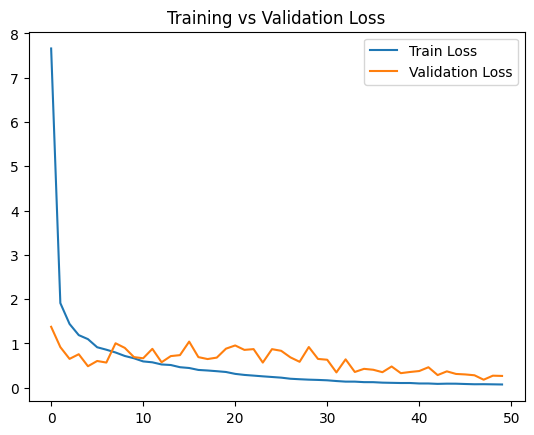

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


#Phase 4

In [6]:
#1. Validation Strategy
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.176, random_state=42
)


In [7]:
#2. Scaling (Consistent with Previous Pipeline)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
#3. Best Model (Random Forest)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train_final)

RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [9]:
#4. Predictions
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

In [10]:
#5. Convert Regression → Classification
import numpy as np

def to_classes(y):
    return np.digitize(y, bins=[5.5, 7.0])

y_val_cls = to_classes(y_val)
y_val_pred_cls = to_classes(y_val_pred)

y_test_cls = to_classes(y_test)
y_test_pred_cls = to_classes(y_test_pred)

In [11]:
#6. Metric Analysis
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

precision = precision_score(y_test_cls, y_test_pred_cls, average='weighted')
recall = recall_score(y_test_cls, y_test_pred_cls, average='weighted')
f1 = f1_score(y_test_cls, y_test_pred_cls, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# AUC-ROC
y_test_bin = label_binarize(y_test_cls, classes=[0,1,2])
y_pred_bin = label_binarize(y_test_pred_cls, classes=[0,1,2])

auc = roc_auc_score(y_test_bin, y_pred_bin, average='weighted', multi_class='ovr')

print("AUC-ROC:", auc)

Precision: 0.9419718092655024
Recall: 0.9418254764292878
F1 Score: 0.9418642149016818
AUC-ROC: 0.9417445635328471


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [12]:
#7. Error Analysis
errors = y_test - y_test_pred

print("Mean Error:", np.mean(errors))
print("Std Dev:", np.std(errors))

import pandas as pd

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred,
    "Error": errors
})

# Top worst predictions
print(error_df.sort_values(by="Error", key=abs, ascending=False).head(10))

Mean Error: -0.0038662650151812996
Std Dev: 0.1551335512698757
      Actual  Predicted     Error
486  8.42530   7.318787  1.106513
338  6.68667   7.739843 -1.053173
364  8.29327   7.310830  0.982440
821  7.27596   7.991967 -0.716007
190  5.89487   6.604175 -0.709305
166  5.99393   6.676630 -0.682700
717  7.24790   7.921640 -0.673740
763  8.65057   7.977744  0.672826
70   9.00546   8.377392  0.628068
367  8.38750   7.839987  0.547513


In [13]:
#8. Bias Check (Feature-Based)
if 'weight' in X_test.columns:
    bias_df = X_test.copy()
    bias_df['Actual'] = y_test
    bias_df['Predicted'] = y_test_pred

    bias_df['Complexity_Group'] = pd.cut(
        bias_df['weight'],
        bins=[0,2,3.5,5],
        labels=['Easy','Medium','Hard']
    )

    print(
        bias_df.groupby('Complexity_Group')[['Actual','Predicted']].mean()
    )

                    Actual  Predicted
Complexity_Group                     
Easy              6.658285   6.670125
Medium            7.074242   7.072643
Hard              7.543623   7.549098


/tmp/ipykernel_900/2210316910.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_df.groupby('Complexity_Group')[['Actual','Predicted']].mean()
